# 1. ResNet을 활용한 이미지 분류

In [4]:
!pip install -q torch torchvision tqdm matplotlib

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1-1. 데이터셋 준비

In [6]:
!pip install -q datasets
from datasets import load_dataset
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

_cifar10 = load_dataset('uoft-cs/cifar10')

class CIFAR10Dataset(torch.utils.data.Dataset):
    def __init__(self, split, transform=None):
        self.data = _cifar10[split]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]['img'], self.data[idx]['label']
        return self.transform(img) if self.transform else img, label

train_dataset = CIFAR10Dataset('train', transform=transform)
test_dataset  = CIFAR10Dataset('test',  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train: 50000, Test: 10000


## 1-2. ResNet 모델 로드

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=True)

# 마지막 FC 레이어를 CIFAR-10 클래스 수(10)에 맞게 교체
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

print(model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Linear(in_features=512, out_features=10, bias=True)


## 1-3. 학습

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}')

Epoch [1/5] Loss: 0.3332


Epoch [2/5] Loss: 0.1282


Epoch [3/5] Loss: 0.0741


Epoch [4/5] Loss: 0.0566


Epoch [5/5] Loss: 0.0453


## 1-4. 평가 및 시각화

ResNet18 Test Accuracy: 94.05%


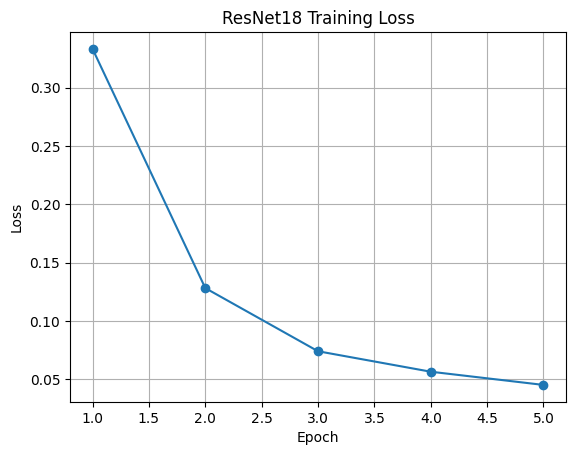

In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100
print(f'ResNet18 Test Accuracy: {accuracy:.2f}%')

plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.title('ResNet18 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## 2. GitHub에 Colab 노트북 업로드하는 방법

Google Colab 노트북을 GitHub에 업로드하는 방법은 다음과 같습니다:

1.  **Colab에서 GitHub에 연결**:
    *   Colab 상단 메뉴에서 `파일(File)` 클릭
    *   `GitHub에 사본 저장...(Save a copy to GitHub...)`을 선택

2.  **GitHub 인증**:
    *   최초 연결 시 GitHub 계정으로 인증을 요청할 수 있습니다. 지시에 따라 인증을 완료하세요.

3.  **저장할 레포지토리(Repository) 선택**:
    *   팝업 창에서 파일을 저장할 GitHub 레포지토리와 브랜치를 선택합니다.
    *   새로운 레포지토리에 저장하고 싶다면, GitHub에서 먼저 레포지토리를 생성해야 합니다.

4.  **파일 이름 및 커밋 메시지 작성**:
    *   파일 이름(예: `ResNet_CIFAR10_Classification.ipynb`)을 확인하거나 변경합니다.
    *   `커밋 메시지(Commit message)`를 작성합니다. (예: `Add ResNet CIFAR-10 classification notebook`)

5.  **저장**:
    *   `확인(OK)` 또는 `저장(Save)` 버튼을 클릭하면 노트북 파일이 선택한 GitHub 레포지토리에 업로드됩니다.